In [16]:
from tests.synthetic_data import make_sceptre_style_synth
from src.sceptre import prepare_crt_inputs
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np


In [2]:
# sythetic data
adata = make_sceptre_style_synth(
    N=10000,
    K=20,
    n_target_genes=200,
    guides_per_gene=6,
    ntc_frac_guides=0.15,
    moi_mean=5.5,
    frac_causal_genes=0.10,
    n_effect_programs=3,
    effect_size=1.2,
    confound_strength=0.0,
    seed=0,
)

In [3]:
adata

AnnData object with n_obs × n_vars = 10000 × 1
    uns: 'guide2gene', 'gene2guides', 'guide_names', 'target_gene_names', 'ntc_gene_name', 'causal_genes', 'gene_effects', 'synth_params'
    obsm: 'covar', 'usage', 'guide_assignment'

In [22]:
# The generator stores usage in adata.obsm["usage"].
# Pass usage_key="usage" when preparing inputs.

inputs = prepare_crt_inputs(
    adata=adata,
    usage_key="cnmf_usage",
    covar_key="covar",
    guide_assignment_key="guide_assignment",
    guide2gene_key="guide2gene"
)

/oak/stanford/groups/engreitz/Users/ymo/Tools/programDE/src/sceptre/adata_utils.py:176: RuntimeWarning: divide by zero encountered in log
  logU = np.log(U2)
/oak/stanford/groups/engreitz/Users/ymo/Tools/programDE/src/sceptre/adata_utils.py:177: RuntimeWarning: invalid value encountered in subtract
  return logU - logU.mean(axis=1, keepdims=True)


In [5]:
from src.sceptre import (
    build_ntc_group_inputs,
    compute_guide_set_null_pvals,
    crt_pvals_for_ntc_groups_ensemble,
    crt_pvals_for_ntc_groups_ensemble_skew,
    make_ntc_groups_ensemble,
    run_all_genes_union_crt,
)
from src.visualization import qq_plot_ntc_pvals

In [6]:

out = run_all_genes_union_crt(
    inputs=inputs,
    B=1023,
    n_jobs=2,
    calibrate_skew_normal=True,
    return_raw_pvals=True,
    return_skew_normal=True,
)


/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

In [10]:

ntc_labels = ["NTC"] # Identify NTC guides and build guide-frequency bins / real-gene signatures
ntc_guides, guide_freq, guide_to_bin, real_sigs = build_ntc_group_inputs(
    inputs=inputs,
    ntc_label=ntc_labels,
    group_size=6,
    n_bins=10,
)

In [12]:


# Create multiple random partitions (ensembles) of NTC guides into 6-guide groups
ntc_groups_ens = make_ntc_groups_ensemble(
    ntc_guides=ntc_guides,
    ntc_freq=guide_freq,
    real_gene_bin_sigs=real_sigs,
    guide_to_bin=guide_to_bin,
    n_ensemble=10,
    seed0=7,
    group_size=6,
    max_groups=None,
)

In [13]:
# Compute raw CRT p-values for each NTC group in each ensemble
ntc_group_pvals_ens = crt_pvals_for_ntc_groups_ensemble(
    inputs=inputs,
    ntc_groups_ens=ntc_groups_ens,
    B=1023,
    seed0=23,
)

/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

In [14]:


# Compute skew-calibrated CRT p-values for each NTC group in each ensemble
ntc_group_pvals_skew_ens = crt_pvals_for_ntc_groups_ensemble_skew(
    inputs=inputs,
    ntc_groups_ens=ntc_groups_ens,
    B=1023,
    seed0=23,
)

/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/programDE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

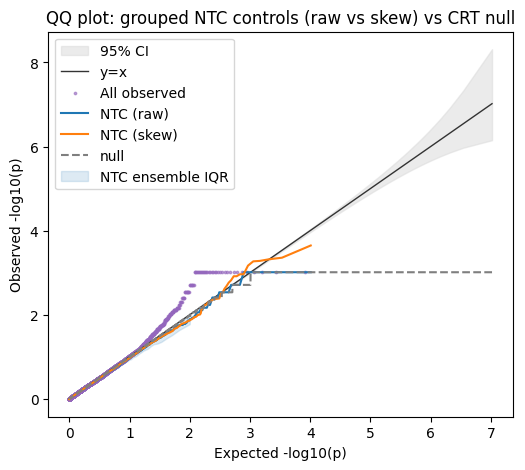

In [15]:

# Build CRT-null p-values matched to NTC group units (recommended)
guide_to_col = {g: i for i, g in enumerate(inputs.guide_names)}
null_pvals = np.concatenate(
    [
        # Each entry is a (B, K) matrix of null p-values for one NTC group
        compute_guide_set_null_pvals(
            guide_idx=[guide_to_col[g] for g in guides],
            inputs=inputs,
            B=1023,
        ).ravel()
        for groups in ntc_groups_ens
        for guides in groups.values()
    ]
)

ax = qq_plot_ntc_pvals(
    pvals_raw_df=out["pvals_raw_df"],
    guide2gene=adata.uns["guide2gene"],
    ntc_genes=ntc_labels,
    pvals_skew_df=out["pvals_df"],
    null_pvals=null_pvals,
    ntc_group_pvals_ens=ntc_group_pvals_ens,
    ntc_group_pvals_skew_ens=ntc_group_pvals_skew_ens,
    show_ntc_ensemble_band=True,
    show_all_pvals=True,
    title="QQ plot: grouped NTC controls (raw vs skew) vs CRT null",
)

import matplotlib.pyplot as plt
plt.show()




